/tmp/ipykernel_944/3224236109.py:22: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Year"] = pd.to_datetime(df["date_time"]).dt.year


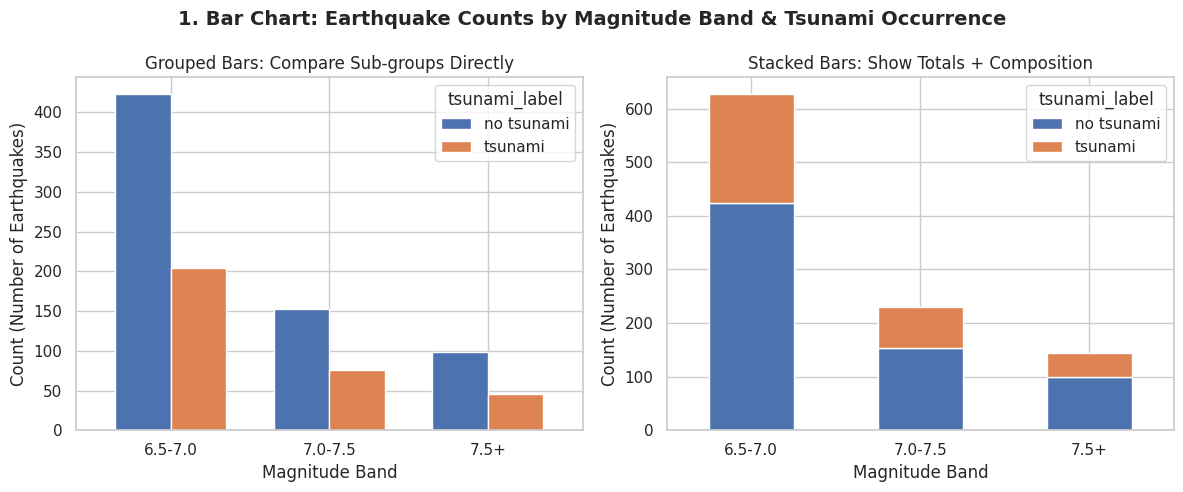

Note: Compares earthquake frequency across magnitude bands and shows the exact split between tsunami and non-tsunami events. Higher magnitude bands exhibit a higher relative proportion of tsunami occurrences.



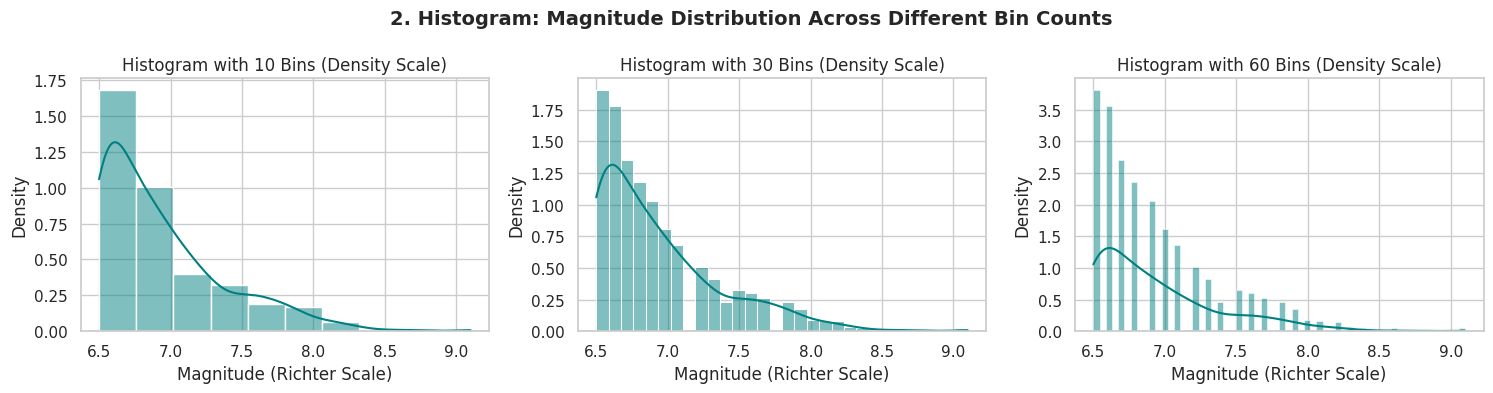

Note: Displays the continuous frequency distribution of earthquake magnitudes. Shows a right-skewed pattern where moderate major earthquakes (6.5–6.8) are frequent, while extreme events (8.0+) are rare.



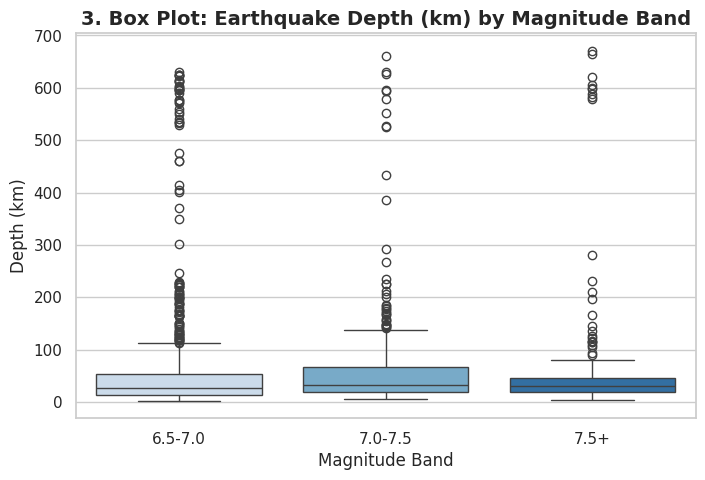

Note: Summarizes focal depth statistics (median, Q1, Q3, IQR, outliers) across magnitude bands. Indicates median depth remains consistently shallow (~20-30 km) across all bands, with deep-focus events appearing as clear statistical outliers.



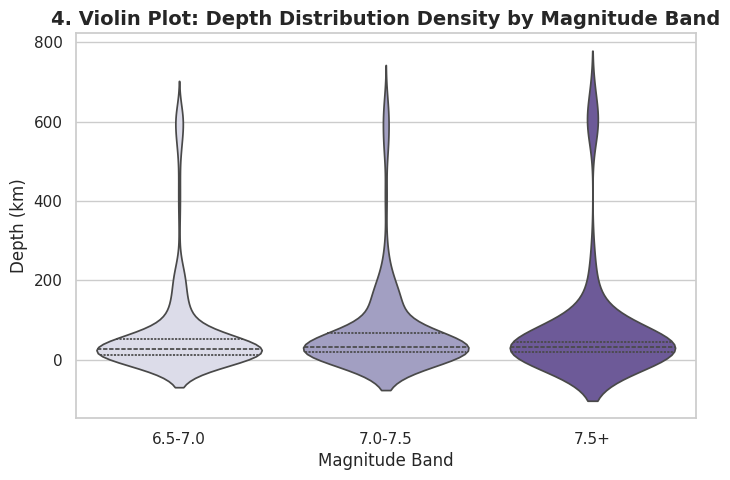

Note: Reveals the full continuous probability density shape of focal depth that box plots hide. Shows a massive concentration of shallow surface quakes (<50 km) and a long, thin tail extending into deep mantle quakes.



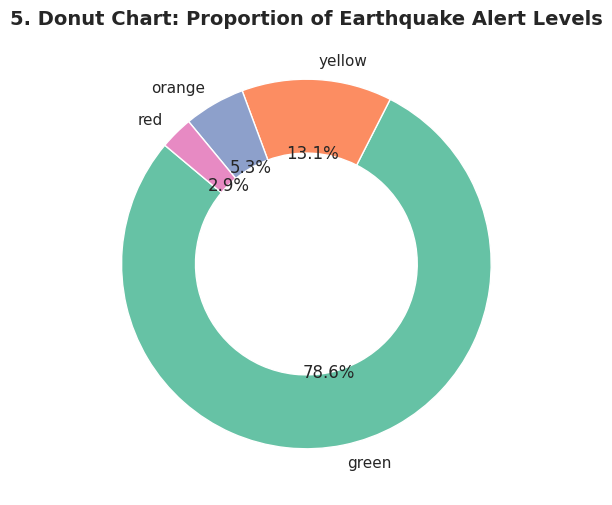

Note: Displays the percentage share of each categorical alert level relative to the entire dataset, highlighting which alert level dominates major seismic events.



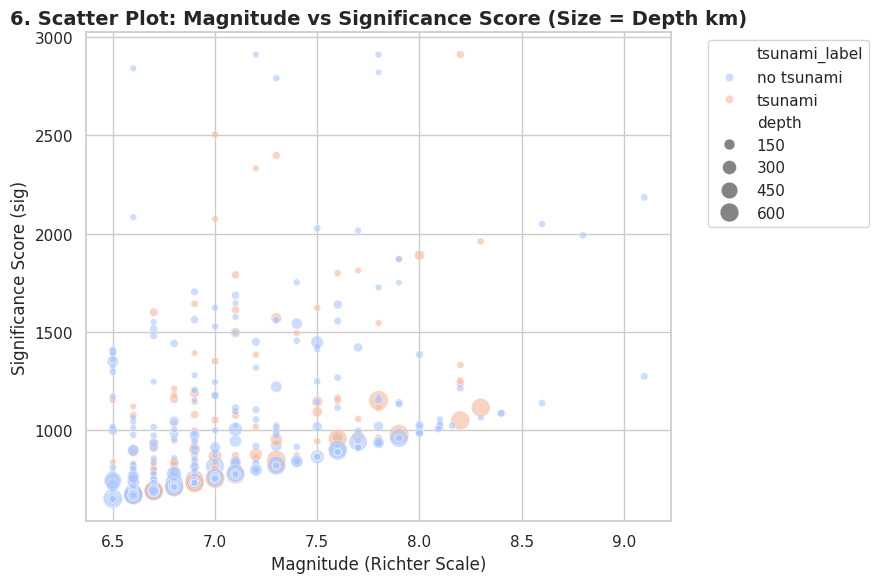

Note: Maps multi-variable relationships by plotting Magnitude vs Significance score, while encoding Depth through dot size and Tsunami occurrence through color. Demonstrates that significance increases with magnitude, but extremely deep quakes often lose surface impact.



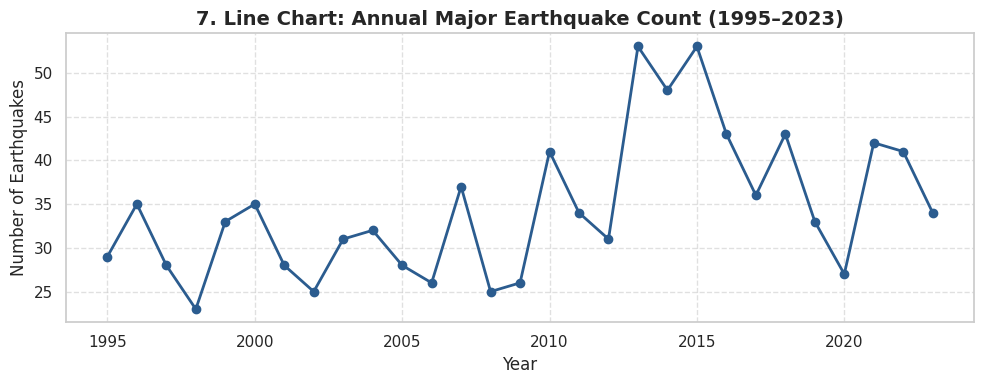

Note: Tracks the temporal trend of annual major earthquake frequency from 1995 to 2023, identifying historical peaks, activity dips, and overall longitudinal stability.



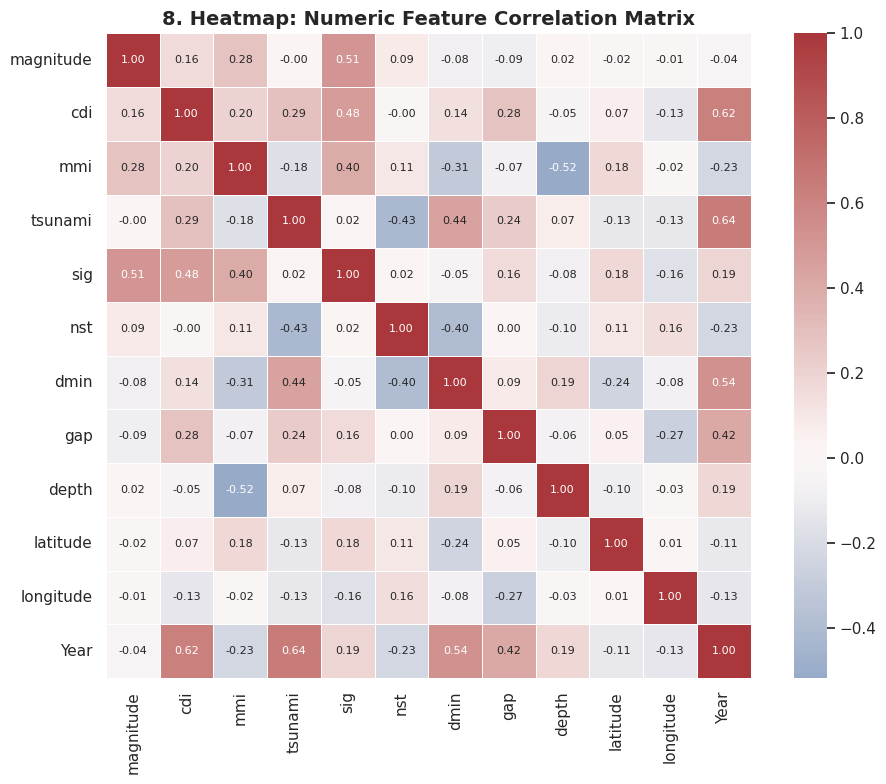

Note: Displays pairwise linear correlation values between all numeric variables. Identifies strong positive linear associations (e.g., magnitude vs significance) and weak or inverse relationships.



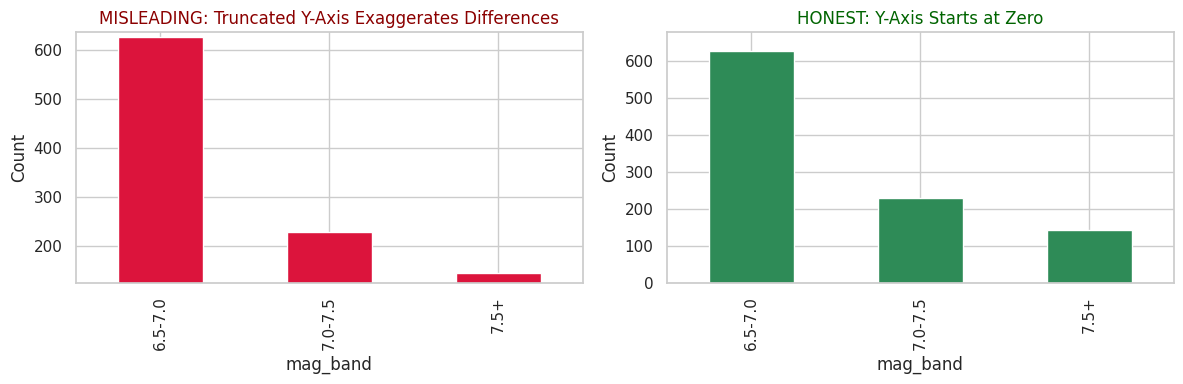

Note on Pair 1:
- Distortion: Truncating the y-axis to start near the minimum bar value instead of zero.
- Deception: Distorts visual proportions, making tiny relative count differences appear massive.
- Correcting Rule: Bar charts must always start their quantitative axis at zero because bar length directly encodes magnitude.



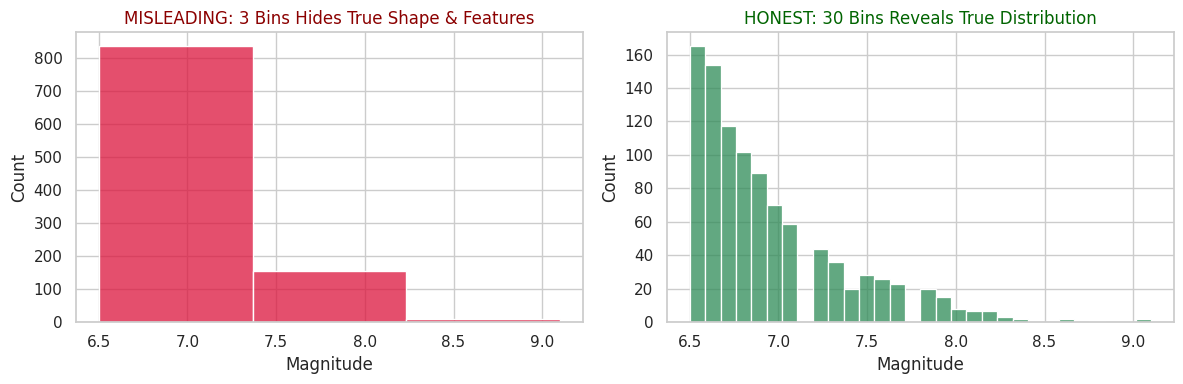

Note on Pair 2:
- Distortion: Over-aggregating continuous numerical data using an extremely small bin count (3 bins).
- Deception: Obscures modal peaks, skewness, and natural data spread, creating a false impression of uniform frequency.
- Correcting Rule: Always test multiple bin counts to select a granular scale that accurately represents the data's true distribution.



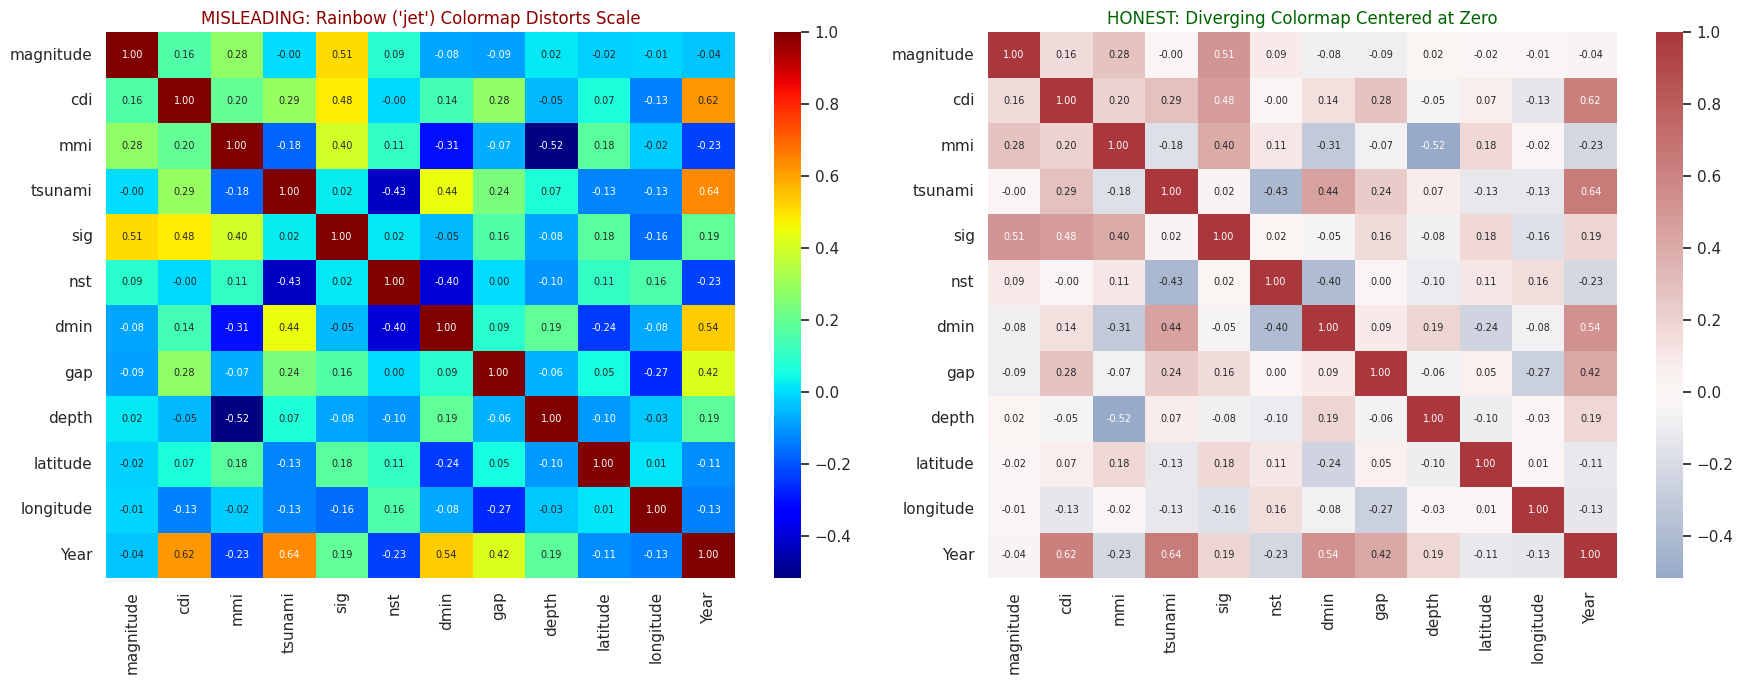

Note on Pair 3:
- Distortion: Using a non-perceptually uniform rainbow ('jet') colormap for continuous correlation values.
- Deception: Rainbow scales introduce artificial visual gradients and exaggerate mid-range changes while hiding true center zeros.
- Correcting Rule: Use perceptually uniform diverging colormaps (e.g., vlag, coolwarm) centered at zero for correlation matrices.


DO AND DON'T SUMMARY FOR HONEST DATA VISUALIZATION
DO:
1. Always start vertical bar chart axes at zero.
2. Choose perceptually uniform and context-appropriate colormaps (e.g., diverging for correlations).
3. Test multiple bin counts on histograms to represent distribution density truthfully.
4. Clearly label all axes, incorporate units, and provide informative titles.

DON'T:
1. Don't truncate axes on bar charts to artificially exaggerate relative variations.
2. Don't use rainbow ('jet') colormaps that distort visual gradients.
3. Don't use 3D pie/donut charts that distort area perception via foreshortening

In [3]:
# ==============================================================================
# LAB ASSIGNMENT 2: DATA VISUALIZATION — CHOOSING & BUILDING HONEST CHARTS
# Course: Data Analytics and Visualization (25CAI202PC201)
# Dataset required: earthquake_1995-2023.csv (placed in the notebook directory)
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set base aesthetic style
sns.set_theme(style="whitegrid")

# ------------------------------------------------------------------------------
# 0. DATA PREPARATION
# ------------------------------------------------------------------------------
df = pd.read_csv("earthquake_1995-2023.csv")

# Extract Year from time column if necessary
if "Year" not in df.columns and "date_time" in df.columns:
    df["Year"] = pd.to_datetime(df["date_time"]).dt.year
elif "Year" not in df.columns and "time" in df.columns:
    df["Year"] = pd.to_datetime(df["time"]).dt.year

# Bin magnitude into categorical bands
bins = [6.5, 7.0, 7.5, 10.0]
labels = ["6.5-7.0", "7.0-7.5", "7.5+"]
df["mag_band"] = pd.cut(df["magnitude"], bins=bins, labels=labels, right=False)
df["tsunami_label"] = df["tsunami"].map({0: "no tsunami", 1: "tsunami"})


# ==============================================================================
# TASK 1 — BUILDING THE CHART FAMILY CORRECTLY (8 CHARTS)
# ==============================================================================

# --- CHART 1: BAR CHART (Grouped & Stacked) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
counts = (
    pd.crosstab(df["mag_band"], df["tsunami_label"])
    .reindex(columns=["no tsunami", "tsunami"])
)

# Grouped Bar Chart
counts.plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"], width=0.7)
axes[0].set_title("Grouped Bars: Compare Sub-groups Directly")
axes[0].set_xlabel("Magnitude Band")
axes[0].set_ylabel("Count (Number of Earthquakes)")
axes[0].tick_params(axis="x", rotation=0)

# Stacked Bar Chart
counts.plot(
    kind="bar", stacked=True, ax=axes[1], color=["#4C72B0", "#DD8452"], width=0.5
)
axes[1].set_title("Stacked Bars: Show Totals + Composition")
axes[1].set_xlabel("Magnitude Band")
axes[1].set_ylabel("Count (Number of Earthquakes)")
axes[1].tick_params(axis="x", rotation=0)

plt.suptitle(
    "1. Bar Chart: Earthquake Counts by Magnitude Band & Tsunami Occurrence",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

print(
    "Note: Compares earthquake frequency across magnitude bands and shows the exact split between tsunami and non-tsunami events. Higher magnitude bands exhibit a higher relative proportion of tsunami occurrences.\n"
)


# --- CHART 2: HISTOGRAM (Multi-bin comparison) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
bin_counts = [10, 30, 60]

for idx, b in enumerate(bin_counts):
    sns.histplot(
        df["magnitude"],
        bins=b,
        kde=True,
        stat="density",
        ax=axes[idx],
        color="teal",
    )
    axes[idx].set_title(f"Histogram with {b} Bins (Density Scale)")
    axes[idx].set_xlabel("Magnitude (Richter Scale)")
    axes[idx].set_ylabel("Density")

plt.suptitle(
    "2. Histogram: Magnitude Distribution Across Different Bin Counts",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

print(
    "Note: Displays the continuous frequency distribution of earthquake magnitudes. Shows a right-skewed pattern where moderate major earthquakes (6.5–6.8) are frequent, while extreme events (8.0+) are rare.\n"
)


# --- CHART 3: BOX PLOT ---
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="mag_band",
    y="depth",
    palette="Blues",
    hue="mag_band",
    legend=False,
)
plt.title(
    "3. Box Plot: Earthquake Depth (km) by Magnitude Band",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Magnitude Band")
plt.ylabel("Depth (km)")
plt.show()

print(
    "Note: Summarizes focal depth statistics (median, Q1, Q3, IQR, outliers) across magnitude bands. Indicates median depth remains consistently shallow (~20-30 km) across all bands, with deep-focus events appearing as clear statistical outliers.\n"
)


# --- CHART 4: VIOLIN PLOT ---
plt.figure(figsize=(8, 5))
sns.violinplot(
    data=df,
    x="mag_band",
    y="depth",
    palette="Purples",
    inner="quartile",
    hue="mag_band",
    legend=False,
)
plt.title(
    "4. Violin Plot: Depth Distribution Density by Magnitude Band",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Magnitude Band")
plt.ylabel("Depth (km)")
plt.show()

print(
    "Note: Reveals the full continuous probability density shape of focal depth that box plots hide. Shows a massive concentration of shallow surface quakes (<50 km) and a long, thin tail extending into deep mantle quakes.\n"
)


# --- CHART 5: DONUT CHART ---
alert_counts = df["alert"].value_counts().dropna()
plt.figure(figsize=(6, 6))
plt.pie(
    alert_counts,
    labels=alert_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("Set2"),
    wedgeprops=dict(width=0.4, edgecolor="white"),
)
plt.title(
    "5. Donut Chart: Proportion of Earthquake Alert Levels",
    fontsize=14,
    fontweight="bold",
)
plt.show()

print(
    "Note: Displays the percentage share of each categorical alert level relative to the entire dataset, highlighting which alert level dominates major seismic events.\n"
)


# --- CHART 6: SCATTER / BUBBLE PLOT ---
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="magnitude",
    y="sig",
    size="depth",
    hue="tsunami_label",
    sizes=(20, 200),
    alpha=0.6,
    palette="coolwarm",
)
plt.title(
    "6. Scatter Plot: Magnitude vs Significance Score (Size = Depth km)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Magnitude (Richter Scale)")
plt.ylabel("Significance Score (sig)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

print(
    "Note: Maps multi-variable relationships by plotting Magnitude vs Significance score, while encoding Depth through dot size and Tsunami occurrence through color. Demonstrates that significance increases with magnitude, but extremely deep quakes often lose surface impact.\n"
)


# --- CHART 7: LINE CHART ---
annual_counts = df.groupby("Year").size()
plt.figure(figsize=(10, 4))
plt.plot(
    annual_counts.index,
    annual_counts.values,
    marker="o",
    color="#2b5c8f",
    linewidth=2,
    markersize=6,
)
plt.title(
    "7. Line Chart: Annual Major Earthquake Count (1995–2023)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Year")
plt.ylabel("Number of Earthquakes")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

print(
    "Note: Tracks the temporal trend of annual major earthquake frequency from 1995 to 2023, identifying historical peaks, activity dips, and overall longitudinal stability.\n"
)


# --- CHART 8: HEATMAP ---
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    cmap="vlag",
    center=0,
    square=True,
    linewidths=0.5,
)
plt.title(
    "8. Heatmap: Numeric Feature Correlation Matrix",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

print(
    "Note: Displays pairwise linear correlation values between all numeric variables. Identifies strong positive linear associations (e.g., magnitude vs significance) and weak or inverse relationships.\n"
)


# ==============================================================================
# TASK 2 — HONEST CHART VS. MISLEADING CHART (3 PAIRS)
# ==============================================================================

# --- PAIR 1: BAR CHART (TRUNCATED Y-AXIS) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cat_counts = df["mag_band"].value_counts().sort_index()

# Misleading
cat_counts.plot(kind="bar", ax=axes[0], color="crimson")
axes[0].set_ylim(cat_counts.min() - 20, cat_counts.max() + 10)
axes[0].set_title(
    "MISLEADING: Truncated Y-Axis Exaggerates Differences", color="darkred"
)
axes[0].set_ylabel("Count")

# Honest
cat_counts.plot(kind="bar", ax=axes[1], color="seagreen")
axes[1].set_ylim(0, cat_counts.max() + 50)
axes[1].set_title("HONEST: Y-Axis Starts at Zero", color="darkgreen")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print("""Note on Pair 1:
- Distortion: Truncating the y-axis to start near the minimum bar value instead of zero.
- Deception: Distorts visual proportions, making tiny relative count differences appear massive.
- Correcting Rule: Bar charts must always start their quantitative axis at zero because bar length directly encodes magnitude.
""")


# --- PAIR 2: HISTOGRAM (TOO FEW BINS) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Misleading
sns.histplot(df["magnitude"], bins=3, ax=axes[0], color="crimson")
axes[0].set_title(
    "MISLEADING: 3 Bins Hides True Shape & Features", color="darkred"
)
axes[0].set_xlabel("Magnitude")

# Honest
sns.histplot(df["magnitude"], bins=30, ax=axes[1], color="seagreen")
axes[1].set_title("HONEST: 30 Bins Reveals True Distribution", color="darkgreen")
axes[1].set_xlabel("Magnitude")

plt.tight_layout()
plt.show()

print("""Note on Pair 2:
- Distortion: Over-aggregating continuous numerical data using an extremely small bin count (3 bins).
- Deception: Obscures modal peaks, skewness, and natural data spread, creating a false impression of uniform frequency.
- Correcting Rule: Always test multiple bin counts to select a granular scale that accurately represents the data's true distribution.
""")


# --- PAIR 3: HEATMAP (RAINBOW / JET COLORMAP) ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Misleading
sns.heatmap(
    corr_matrix,
    ax=axes[0],
    cmap="jet",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7},
    cbar=True,
)
axes[0].set_title(
    "MISLEADING: Rainbow ('jet') Colormap Distorts Scale", color="darkred"
)

# Honest
sns.heatmap(
    corr_matrix,
    ax=axes[1],
    cmap="vlag",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7},
    cbar=True,
)
axes[1].set_title(
    "HONEST: Diverging Colormap Centered at Zero", color="darkgreen"
)

plt.tight_layout()
plt.show()

print("""Note on Pair 3:
- Distortion: Using a non-perceptually uniform rainbow ('jet') colormap for continuous correlation values.
- Deception: Rainbow scales introduce artificial visual gradients and exaggerate mid-range changes while hiding true center zeros.
- Correcting Rule: Use perceptually uniform diverging colormaps (e.g., vlag, coolwarm) centered at zero for correlation matrices.
""")


# ------------------------------------------------------------------------------
# SUMMARY OF GOOD VISUALIZATION PRACTICE
# ------------------------------------------------------------------------------
print("""
==============================================================================
DO AND DON'T SUMMARY FOR HONEST DATA VISUALIZATION
==============================================================================
DO:
1. Always start vertical bar chart axes at zero.
2. Choose perceptually uniform and context-appropriate colormaps (e.g., diverging for correlations).
3. Test multiple bin counts on histograms to represent distribution density truthfully.
4. Clearly label all axes, incorporate units, and provide informative titles.

DON'T:
1. Don't truncate axes on bar charts to artificially exaggerate relative variations.
2. Don't use rainbow ('jet') colormaps that distort visual gradients.
3. Don't use 3D pie/donut charts that distort area perception via foreshortening.
4. Don't over-aggregate continuous variables into too few bins.
==============================================================================
""")